# Projeto Final - Deep Learning com Transformers

## Clusterização de Textos com BERTimbau, NER Setorial e Representação Híbrida

**Matheus Lira** — versão melhorada

Este notebook implementa uma abordagem aprimorada para clusterização de projetos científicos brasileiros, combinando:
- **BERTimbau** (`neuralmind/bert-base-portuguese-cased`) com mean pooling e processamento em lotes
- **Pré-filtro temático** com ~63 termos para selecionar textos de setores não-tecnológicos
- **NER setorial** treinado com spaCy para extrair entidades por setor
- **Representação híbrida** (BERT + TF-IDF + NER + Pré-filtro) com pesos calibrados
- **Clusterização focada** apenas no subconjunto setorial (~8-10% do corpus)

In [1]:
!pip install -q transformers sentencepiece spacy nltk
!python -m spacy download pt_core_news_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 59.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import os, re, random, unicodedata
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize, StandardScaler
from scipy.spatial.distance import cdist

import torch
from transformers import AutoTokenizer, AutoModel

import spacy
from spacy.training import Example
from spacy.util import minibatch, compounding

import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

RANDOM_STATE = 42
OUTPUT_DIR = "/kaggle/working"
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [3]:
print("PyTorch:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo:", device)

PyTorch: 2.10.0+cu128
Dispositivo: cuda


# Carregamento do Dataset

Nesta etapa será realizado o carregamento do conjunto de dados disponibilizado pelo professor. Também serão verificadas a estrutura do dataset, a quantidade de registros e os tipos das variáveis antes do início do pré-processamento.

In [4]:
import pandas as pd

# Caminho do arquivo
caminho = "/kaggle/input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv"

# Carregando o dataset
df = pd.read_csv(
    caminho,
    sep="\t",
    encoding="latin-1"
)

print(f"Dataset carregado com sucesso!")
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

Dataset carregado com sucesso!
Linhas: 2725
Colunas: 2


In [5]:
# Visualizando as primeiras linhas
display(df.head())

print("\nInformações do dataset:")
display(df.info())

print("\nNomes das colunas:")
print(df.columns.tolist())

,Título_Público,Descricao_pública
0,Açúcar de frutas e aplicação em bolos como sub...,O uso de inovações tecnológicas auxilia as ind...
1,Desenvolver uma linha de farofas com castanhas...,O uso de inovações tecnológicas auxilia as ind...
2,Desenvolvimento de cobertura líquida para sorvete,O Brasil é considerado um país com a maior bio...
3,Desenvolvimento de conserva de tomate cereja,O Brasil é considerado o país com maior biodiv...
4,Desenvolvimento de massa alimentícia enriqueci...,Nos últimos anos a comunidade científica tem d...



Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2725 entries, 0 to 2724
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Título_Público     2722 non-null   object
 1   Descricao_pública  2721 non-null   object
dtypes: object(2)
memory usage: 42.7+ KB


None


Nomes das colunas:
['Título_Público', 'Descricao_pública']


In [6]:
# Removendo registros com valores nulos
df = df.dropna(subset=["Título_Público", "Descricao_pública"])

# Removendo registros duplicados
df = df.drop_duplicates()

# Reiniciando o índice
df = df.reset_index(drop=True)

print(f"Quantidade de registros após limpeza: {len(df)}")

Quantidade de registros após limpeza: 2719


In [7]:
# Criando uma única coluna de texto
# O título é repetido para dar mais importância ao tema principal do projeto

df["texto"] = (
    df["Título_Público"].astype(str) + ". " +
    df["Título_Público"].astype(str) + ". " +
    df["Descricao_pública"].astype(str)
)

# Visualizando alguns exemplos
df[["Título_Público", "texto"]].head()

,Título_Público,texto
0,Açúcar de frutas e aplicação em bolos como sub...,Açúcar de frutas e aplicação em bolos como sub...
1,Desenvolver uma linha de farofas com castanhas...,Desenvolver uma linha de farofas com castanhas...
2,Desenvolvimento de cobertura líquida para sorvete,Desenvolvimento de cobertura líquida para sorv...
3,Desenvolvimento de conserva de tomate cereja,Desenvolvimento de conserva de tomate cereja. ...
4,Desenvolvimento de massa alimentícia enriqueci...,Desenvolvimento de massa alimentícia enriqueci...


In [8]:
# Calculando o tamanho dos textos em caracteres
df["tamanho_texto"] = df["texto"].str.len()

print(f"Quantidade de documentos: {len(df)}")
print(f"Tamanho médio: {df['tamanho_texto'].mean():.0f} caracteres")
print(f"Menor texto: {df['tamanho_texto'].min()} caracteres")
print(f"Maior texto: {df['tamanho_texto'].max()} caracteres")

df["tamanho_texto"].describe()

Quantidade de documentos: 2719
Tamanho médio: 477 caracteres
Menor texto: 7 caracteres
Maior texto: 3263 caracteres


count    2719.000000
mean      476.754689
std       415.021283
min         7.000000
25%       212.000000
50%       357.000000
75%       593.000000
max      3263.000000
Name: tamanho_texto, dtype: float64

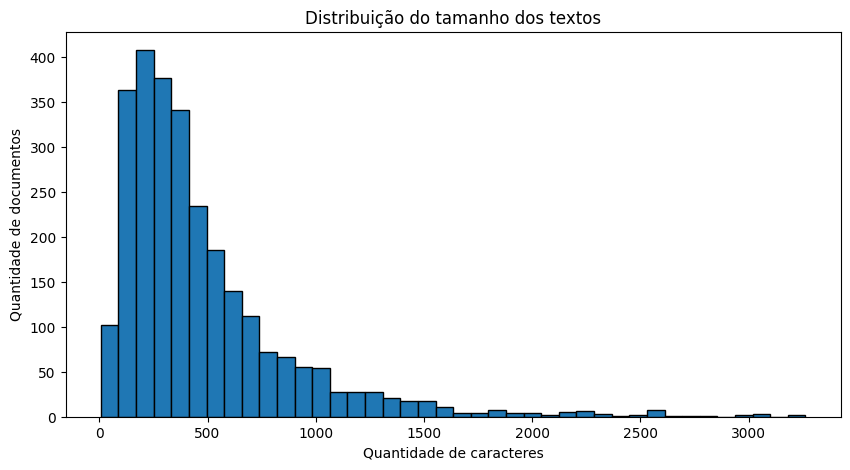

In [9]:
plt.figure(figsize=(10,5))

plt.hist(df["tamanho_texto"], bins=40, edgecolor="black")

plt.title("Distribuição do tamanho dos textos")
plt.xlabel("Quantidade de caracteres")
plt.ylabel("Quantidade de documentos")

plt.show()

# 2. Pré-filtro Temático (~63 termos, 7 categorias)

Antes de gerar os embeddings, aplicamos um pré-filtro baseado em termos-chave para identificar
textos de setores corporativos **não-tecnológicos**. Os textos que passam no filtro (~8-10% do corpus)
serão usados como base da clusterização. Os demais (tecnologia, IA, software) recebem `cluster_final = -1`.

O pré-filtro tem duas funções:
1. **Selecionar** os textos relevantes para clustering setorial
2. **Contribuir como Block 4** na representação híbrida (vetor binário de 7 dimensões)

In [10]:
PRE_FILTRO = {
    'SAUDE_FARMACIA': [
        'farmacêutico', 'medicamento', 'fármaco', 'vacina', 'vacinas',
        'antibiótico', 'biotecnologia', 'diagnóstico clínico', 'biofármaco',
        'proteína terapêutica', 'terapia celular', 'ensaio clínico',
    ],
    'AGRONEGOCIO_PECUARIA': [
        'soja', 'milho', 'plantio', 'colheita', 'pecuária',
        'irrigação', 'adubação', 'herbicida', 'defensivo agrícola',
        'cultura de soja', 'manejo de pastagem', 'gado bovino',
    ],
    'ALIMENTOS_BEBIDAS': [
        'sorvete', 'iogurte', 'queijo', 'cerveja', 'laticínio',
        'panificação', 'embutido', 'frigorífico', 'fermentação alimentar',
        'processamento de carnes', 'bebida fermentada', 'farinha de trigo',
    ],
    'ENERGIA_RENOVAVEL': [
        'energia solar', 'energia eólica', 'fotovoltaico', 'biodiesel',
        'biogás', 'etanol', 'biomassa', 'célula combustível',
        'eficiência energética', 'geração distribuída',
    ],
    'PETROLEO_GAS': [
        'petróleo', 'gás natural', 'offshore', 'hidrocarboneto',
        'refinaria', 'duto', 'poço de petróleo', 'óleo diesel',
        'corrosão em dutos', 'exploração de petróleo',
    ],
    'AMBIENTAL_RESIDUOS': [
        'efluente industrial', 'efluentes industriais', 'resíduo sólido',
        'resíduos sólidos', 'saneamento básico', 'reciclagem de material',
        'aterro sanitário', 'chorume', 'compostagem', 'poluição ambiental',
        'gestão ambiental', 'tratamento de efluentes',
    ],
    'COSMETICA_HIGIENE': [
        'cosmético', 'cosméticos', 'formulação cosmética', 'emulsão cosmética',
        'protetor solar', 'shampoo', 'hidratante facial', 'perfume',
        'higiene pessoal', 'condicionador',
    ],
}

In [11]:
def normalizar(texto):
    nfkd = unicodedata.normalize('NFKD', str(texto))
    return ''.join(c for c in nfkd if not unicodedata.combining(c)).lower()

def checar_prefiltro(texto):
    texto_norm = normalizar(texto)
    return {
        cat: int(any(
            re.search(r'(?<!\w)' + re.escape(normalizar(t)) + r'(?!\w)', texto_norm)
            for t in termos
        ))
        for cat, termos in PRE_FILTRO.items()
    }

print("Aplicando pré-filtro...")
features_pre_filtro = np.array([
    list(checar_prefiltro(t).values()) for t in df['texto']
])

n_setorial = (features_pre_filtro.sum(axis=1) > 0).sum()
print(f"Textos com sinal setorial: {n_setorial} ({n_setorial/len(df):.1%} do total)")
print()
print("Cobertura por categoria:")
for i, cat in enumerate(PRE_FILTRO.keys()):
    n = int(features_pre_filtro[:, i].sum())
    print(f"  {cat}: {n} textos ({n/len(df):.1%})")

Aplicando pré-filtro...
Textos com sinal setorial: 260 (9.6% do total)

Cobertura por categoria:
  SAUDE_FARMACIA: 21 textos (0.8%)
  AGRONEGOCIO_PECUARIA: 81 textos (3.0%)
  ALIMENTOS_BEBIDAS: 6 textos (0.2%)
  ENERGIA_RENOVAVEL: 96 textos (3.5%)
  PETROLEO_GAS: 37 textos (1.4%)
  AMBIENTAL_RESIDUOS: 23 textos (0.8%)
  COSMETICA_HIGIENE: 11 textos (0.4%)


# 3. Análise de Ambiguidade

Termos que aparecem em múltiplos setores geram risco de classificação cruzada
(o que o professor chama de *princípio de alucinação*).
Identificar esses casos antes do treinamento permite escolher termos de referência mais específicos.

In [12]:
TERMOS_AMBIGUOS = {
    'manga':    'fruta (ALIMENTOS) ou manga de roupa (irrelevante)',
    'cultura':  'cultura de soja (AGRONEGOCIO) ou cultura organizacional (irrelevante)',
    'óleo':     'óleo vegetal (ALIMENTOS) ou óleo mineral (PETROLEO_GAS)',
    'extrato':  'extrato vegetal (COSMETICA/ALIMENTOS) ou extrato financeiro (irrelevante)',
    'cana':     'cana-de-açúcar (AGRONEGOCIO) ou cana (tubulação, ENGENHARIA)',
    'fermento': 'fermentação alimentar (ALIMENTOS) ou biotecnologia (SAUDE)',
    'biogás':   'biogás (ENERGIA_RENOVAVEL) ou biogás em aterro (AMBIENTAL)',
    'efluente': 'efluente industrial (AMBIENTAL) ou efluente da agroindústria (AGRONEGOCIO)',
}

print("Termos potencialmente ambíguos:")
print("-" * 65)
for termo, descricao in TERMOS_AMBIGUOS.items():
    n = df['texto'].str.lower().str.contains(
        r'(?<!\w)' + re.escape(termo) + r'(?!\w)', regex=True
    ).sum()
    print(f"  '{termo}' ({n} ocorrências): {descricao}")

Termos potencialmente ambíguos:
-----------------------------------------------------------------
  'manga' (1 ocorrências): fruta (ALIMENTOS) ou manga de roupa (irrelevante)
  'cultura' (34 ocorrências): cultura de soja (AGRONEGOCIO) ou cultura organizacional (irrelevante)
  'óleo' (50 ocorrências): óleo vegetal (ALIMENTOS) ou óleo mineral (PETROLEO_GAS)
  'extrato' (10 ocorrências): extrato vegetal (COSMETICA/ALIMENTOS) ou extrato financeiro (irrelevante)
  'cana' (32 ocorrências): cana-de-açúcar (AGRONEGOCIO) ou cana (tubulação, ENGENHARIA)
  'fermento' (3 ocorrências): fermentação alimentar (ALIMENTOS) ou biotecnologia (SAUDE)
  'biogás' (6 ocorrências): biogás (ENERGIA_RENOVAVEL) ou biogás em aterro (AMBIENTAL)
  'efluente' (5 ocorrências): efluente industrial (AMBIENTAL) ou efluente da agroindústria (AGRONEGOCIO)


# 4. NER Setorial com spaCy

Treinamos um modelo NER a partir do zero (`spacy.blank("pt")`) usando os textos
do pré-filtro como dado de treinamento. As entidades são extraídas por correspondência
de termos de referência via regex com fronteiras de palavra (`(?<!\w)termo(?!\w)`).

In [13]:
LABELS_NER = {
    'SAUDE_FARMACIA_BIOTEC': {
        'termos_referencia': [
            'farmacêutico', 'medicamento', 'fármaco', 'vacina',
            'antibiótico', 'biofármaco', 'proteína terapêutica', 'ensaio clínico',
        ]
    },
    'AGRONEGOCIO_PECUARIA': {
        'termos_referencia': [
            'soja', 'milho', 'plantio', 'colheita',
            'pecuária', 'irrigação', 'adubação', 'gado bovino',
        ]
    },
    'ALIMENTOS_BEBIDAS_NUTRICAO': {
        'termos_referencia': [
            'sorvete', 'iogurte', 'queijo', 'cerveja',
            'frigorífico', 'panificação', 'laticínio', 'embutido',
        ]
    },
    'ENERGIA_RENOVAVEL': {
        'termos_referencia': [
            'energia solar', 'fotovoltaico', 'biodiesel', 'biogás',
            'etanol', 'biomassa', 'energia eólica', 'célula combustível',
        ]
    },
    'PETROLEO_GAS_MINERACAO': {
        'termos_referencia': [
            'petróleo', 'gás natural', 'offshore', 'hidrocarboneto',
            'refinaria', 'duto', 'poço de petróleo',
        ]
    },
    'AMBIENTAL_RESIDUOS_AGUA': {
        'termos_referencia': [
            'resíduo sólido', 'resíduos sólidos', 'tratamento de efluentes',
            'saneamento básico', 'aterro sanitário', 'chorume', 'compostagem',
        ]
    },
    'COSMETICA_HIGIENE_PESSOAL': {
        'termos_referencia': [
            'cosmético', 'cosméticos', 'formulação cosmética', 'emulsão cosmética',
            'protetor solar', 'shampoo', 'hidratante facial',
        ]
    },
}

In [14]:
def extrair_entidades(texto, labels_ner):
    texto_norm = normalizar(texto)
    entidades = []
    for label, cfg in labels_ner.items():
        for termo in cfg['termos_referencia']:
            padrao = r'(?<!\w)' + re.escape(normalizar(termo)) + r'(?!\w)'
            for m in re.finditer(padrao, texto_norm):
                entidades.append((m.start(), m.end(), label))
    # Remove sobreposições (mantém a primeira)
    entidades.sort(key=lambda x: x[0])
    limpos = []
    ultimo_fim = -1
    for ini, fim, lab in entidades:
        if ini >= ultimo_fim:
            limpos.append((ini, fim, lab))
            ultimo_fim = fim
    return limpos

In [15]:
MAX_EXEMPLOS = 120
mask_set = features_pre_filtro.sum(axis=1) > 0
df_set_train = df[mask_set].copy().reset_index(drop=True)
print(f"Textos setoriais disponíveis: {len(df_set_train)}")

TRAINING_DATA = []
contagem = {label: 0 for label in LABELS_NER}

for _, row in df_set_train.iterrows():
    texto = row['texto']
    spans = extrair_entidades(texto, LABELS_NER)
    if not spans:
        continue
    # Label dominante no texto
    from collections import Counter
    dom = Counter(l for _, _, l in spans).most_common(1)[0][0]
    if contagem[dom] >= MAX_EXEMPLOS:
        continue
    contagem[dom] += 1
    TRAINING_DATA.append((texto, {'entities': spans}))

print(f"Total de exemplos: {len(TRAINING_DATA)}")
for label, n in sorted(contagem.items(), key=lambda x: -x[1]):
    print(f"  {label}: {n}")

Textos setoriais disponíveis: 260
Total de exemplos: 224
  AGRONEGOCIO_PECUARIA: 72
  ENERGIA_RENOVAVEL: 69
  PETROLEO_GAS_MINERACAO: 37
  AMBIENTAL_RESIDUOS_AGUA: 21
  SAUDE_FARMACIA_BIOTEC: 13
  COSMETICA_HIGIENE_PESSOAL: 8
  ALIMENTOS_BEBIDAS_NUTRICAO: 4


In [16]:
from spacy.training import offsets_to_biluo_tags

nlp_temp = spacy.blank("pt")
TRAINING_VALID = []
erros = 0

for texto, anot in TRAINING_DATA:
    doc = nlp_temp.make_doc(texto)
    try:
        tags = offsets_to_biluo_tags(doc, anot['entities'])
        if '-' not in tags:
            TRAINING_VALID.append((texto, anot))
    except Exception:
        erros += 1

print(f"Exemplos válidos: {len(TRAINING_VALID)} | Descartados: {erros}")

Exemplos válidos: 220 | Descartados: 0


Epoch 5/30 — loss: 179.5044
Epoch 10/30 — loss: 268.1028
Epoch 15/30 — loss: 290.2532
Epoch 20/30 — loss: 31.2214
Epoch 25/30 — loss: 4.8384
Epoch 30/30 — loss: 15.0474


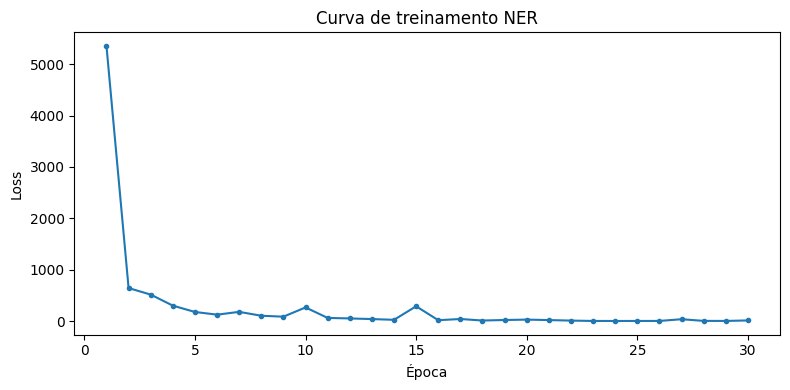

In [17]:
nlp_ner = spacy.blank("pt")
ner_pipe = nlp_ner.add_pipe("ner")
for label in LABELS_NER:
    ner_pipe.add_label(label)

optimizer = nlp_ner.begin_training()
N_EPOCHS = 30
historico_loss = []

for epoch in range(N_EPOCHS):
    random.shuffle(TRAINING_VALID)
    losses = {}
    batches = minibatch(TRAINING_VALID, size=compounding(4.0, 32.0, 1.001))
    for batch in batches:
        examples = [
            Example.from_dict(nlp_ner.make_doc(txt), ann)
            for txt, ann in batch
        ]
        nlp_ner.update(examples, drop=0.35, losses=losses)
    historico_loss.append(losses.get('ner', 0))
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{N_EPOCHS} — loss: {losses.get('ner', 0):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, N_EPOCHS + 1), historico_loss, marker='o', markersize=3)
plt.title('Curva de treinamento NER')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

In [18]:
n_val = max(1, int(len(TRAINING_VALID) * 0.2))
dados_val = TRAINING_VALID[-n_val:]

y_true, y_pred = [], []
for texto, anot in dados_val:
    doc = nlp_ner(texto)
    pred_map = {(e.start_char, e.end_char): e.label_ for e in doc.ents}
    for ini, fim, label in anot['entities']:
        y_true.append(label)
        y_pred.append(pred_map.get((ini, fim), 'O'))

from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, labels=list(LABELS_NER.keys()), zero_division=0))

                            precision    recall  f1-score   support

     SAUDE_FARMACIA_BIOTEC       1.00      1.00      1.00         2
      AGRONEGOCIO_PECUARIA       1.00      1.00      1.00        41
ALIMENTOS_BEBIDAS_NUTRICAO       0.00      0.00      0.00         0
         ENERGIA_RENOVAVEL       1.00      1.00      1.00        41
    PETROLEO_GAS_MINERACAO       1.00      1.00      1.00        15
   AMBIENTAL_RESIDUOS_AGUA       1.00      1.00      1.00        10
 COSMETICA_HIGIENE_PESSOAL       1.00      1.00      1.00         6

                  accuracy                           1.00       115
                 macro avg       0.86      0.86      0.86       115
              weighted avg       1.00      1.00      1.00       115



In [19]:
print("Aplicando NER ao corpus completo...")
df['entidades_ner'] = df['texto'].apply(
    lambda t: [(e.text, e.label_) for e in nlp_ner(str(t)).ents]
)

for label in LABELS_NER:
    df[f'ner_{label}'] = df['entidades_ner'].apply(
        lambda ents: sum(1 for _, l in ents if l == label)
    )

total_ner = (df[[f'ner_{l}' for l in LABELS_NER]].sum(axis=1) > 0).sum()
print(f"Textos com entidades NER: {total_ner} ({total_ner/len(df):.1%})")
for label in LABELS_NER:
    print(f"  {label}: {int(df[f'ner_{label}'].sum())} entidades")

Aplicando NER ao corpus completo...
Textos com entidades NER: 245 (9.0%)
  SAUDE_FARMACIA_BIOTEC: 28 entidades
  AGRONEGOCIO_PECUARIA: 206 entidades
  ALIMENTOS_BEBIDAS_NUTRICAO: 20 entidades
  ENERGIA_RENOVAVEL: 181 entidades
  PETROLEO_GAS_MINERACAO: 80 entidades
  AMBIENTAL_RESIDUOS_AGUA: 48 entidades
  COSMETICA_HIGIENE_PESSOAL: 19 entidades


# 5. Embeddings BERTimbau

Usamos **mean pooling** (média sobre todos os tokens) e processamento em **lotes de 16**, com `max_length=256`.

In [20]:
import os
from transformers import AutoTokenizer, AutoModel
import torch

NOME_MODELO = "neuralmind/bert-base-portuguese-cased"

# No Kaggle sem internet, tenta carregar via kagglehub ou caminho local
def carregar_bert():
    # Tentativa 1: download direto (funciona com internet habilitada)
    try:
        tok = AutoTokenizer.from_pretrained(NOME_MODELO)
        mod = AutoModel.from_pretrained(NOME_MODELO)
        print("Modelo carregado via HuggingFace Hub.")
        return tok, mod
    except Exception:
        pass

    # Tentativa 2: kagglehub
    try:
        import kagglehub
        caminho = kagglehub.model_download("neuralmind/bert-base-portuguese-cased/transformers/default")
        tok = AutoTokenizer.from_pretrained(caminho)
        mod = AutoModel.from_pretrained(caminho)
        print(f"Modelo carregado via kagglehub: {caminho}")
        return tok, mod
    except Exception:
        pass

    # Tentativa 3: caminho local padrão do Kaggle para modelos adicionados manualmente
    for caminho_local in [
        "/kaggle/input/bert-base-portuguese-cased",
        "/kaggle/input/neuralmind-bert-base-portuguese-cased",
        "/root/.cache/huggingface/hub",
    ]:
        if os.path.exists(caminho_local):
            try:
                tok = AutoTokenizer.from_pretrained(caminho_local)
                mod = AutoModel.from_pretrained(caminho_local)
                print(f"Modelo carregado do caminho local: {caminho_local}")
                return tok, mod
            except Exception:
                continue

    raise RuntimeError(
        "Nao foi possivel carregar o BERTimbau. "
        "Habilite a internet no Kaggle (Settings > Internet > On) e re-execute."
    )

tokenizer, bert = carregar_bert()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert.to(device)

print(f"Dispositivo: {device}")

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo carregado via HuggingFace Hub.
Dispositivo: cuda


In [21]:
# Função para um único texto (manutenção/testes)
def gerar_embedding(texto):
    inputs = tokenizer(
        str(texto), return_tensors='pt',
        truncation=True, padding=True, max_length=256
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = bert(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()

# Função em lote — muito mais rápida
def gerar_embeddings_lote(textos, batch_size=16):
    todos = []
    n = len(textos)
    for i in range(0, n, batch_size):
        lote = [str(t) for t in textos[i:i + batch_size]]
        inputs = tokenizer(lote, return_tensors='pt',
                           truncation=True, padding=True, max_length=256)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = bert(**inputs)
        todos.append(outputs.last_hidden_state.mean(dim=1).cpu().numpy())
        if (i // batch_size) % 10 == 0:
            print(f"  Lote {i//batch_size + 1}/{(n-1)//batch_size + 1}", end='\r')
    print()
    return np.vstack(todos)

In [22]:
print("Gerando embeddings (texto original)...")
X = gerar_embeddings_lote(df['texto'].tolist())
print(f"Shape embeddings: {X.shape}")

Gerando embeddings (texto original)...


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

  Lote 161/170
Shape embeddings: (2719, 768)


# 6. Texto Enriquecido com Entidades NER

Concatenamos marcadores semânticos ao texto original (`[ENTIDADE_LABEL]`),
gerando uma segunda representação BERT que incorpora explicitamente as entidades detectadas.

In [23]:
def enriquecer_texto(row):
    texto_base = row['texto']
    tags = [f'[ENTIDADE_{l}]' for _, l in row['entidades_ner']]
    return (texto_base + ' ' + ' '.join(tags)) if tags else texto_base

df['texto_enriquecido'] = df.apply(enriquecer_texto, axis=1)

exemplo = df[df['entidades_ner'].apply(len) > 0].iloc[0]
print("Exemplo de texto enriquecido:")
print(exemplo['texto_enriquecido'][:300])

Exemplo de texto enriquecido:
Desenvolvimento de cobertura líquida para sorvete. Desenvolvimento de cobertura líquida para sorvete. O Brasil é considerado um país com a maior biodiversidade do mundo, com diferentes espécies nos biomas da Amazônia, Mata Atlântica e Cerrado, onde são encontradas plantas frutíferas nativas e import


In [24]:
print("Gerando embeddings (texto enriquecido)...")
X_enriquecido = gerar_embeddings_lote(df['texto_enriquecido'].tolist())
print(f"Shape: {X_enriquecido.shape}")

Gerando embeddings (texto enriquecido)...
  Lote 161/170
Shape: (2719, 768)


# 7. Representação Híbrida (4 Blocos)

| Bloco | Fonte | Dimensões | Peso |
|-------|-------|-----------|------|
| 1 | BERT mean pooling + PCA | 100d | 0.6 |
| 2 | TF-IDF + SVD | 50d | 0.8 |
| 3 | Contagem de entidades NER | 7d | 2.5 |
| 4 | Pré-filtro binário | 7d | 2.5 |

Os pesos amplificam os sinais setoriais esparsos (NER e pré-filtro) para compensar
a dominância dos embeddings BERT densos.

In [25]:
# Block 1 — BERT PCA 100d
pca_bert = PCA(n_components=100, random_state=RANDOM_STATE)
bloco1 = pca_bert.fit_transform(normalize(X, norm='l2'))
print(f"Block 1 (BERT PCA): {bloco1.shape}")

Block 1 (BERT PCA): (2719, 100)


In [26]:
# Block 2 — TF-IDF + SVD 50d
stop_pt = list(stopwords.words('portuguese'))
vec_tfidf = TfidfVectorizer(stop_words=stop_pt, max_features=8000, ngram_range=(1, 2))
tfidf_mat = vec_tfidf.fit_transform(df['texto'])
svd = TruncatedSVD(n_components=50, random_state=RANDOM_STATE)
bloco2 = svd.fit_transform(tfidf_mat)
print(f"Block 2 (TF-IDF SVD): {bloco2.shape}")

Block 2 (TF-IDF SVD): (2719, 50)


In [27]:
# Block 3 — contagem de entidades NER (7d)
cols_ner = [f'ner_{label}' for label in LABELS_NER]
bloco3 = df[cols_ner].values.astype(float)
print(f"Block 3 (NER): {bloco3.shape}")
print(f"Labels: {list(LABELS_NER.keys())}")

Block 3 (NER): (2719, 7)
Labels: ['SAUDE_FARMACIA_BIOTEC', 'AGRONEGOCIO_PECUARIA', 'ALIMENTOS_BEBIDAS_NUTRICAO', 'ENERGIA_RENOVAVEL', 'PETROLEO_GAS_MINERACAO', 'AMBIENTAL_RESIDUOS_AGUA', 'COSMETICA_HIGIENE_PESSOAL']


In [28]:
# Block 4 — features binárias do pré-filtro (7d)
bloco4 = features_pre_filtro.astype(float)
print(f"Block 4 (Pré-filtro): {bloco4.shape}")
print(f"Categorias: {list(PRE_FILTRO.keys())}")

Block 4 (Pré-filtro): (2719, 7)
Categorias: ['SAUDE_FARMACIA', 'AGRONEGOCIO_PECUARIA', 'ALIMENTOS_BEBIDAS', 'ENERGIA_RENOVAVEL', 'PETROLEO_GAS', 'AMBIENTAL_RESIDUOS', 'COSMETICA_HIGIENE']


In [29]:
PESOS = {'bert': 0.6, 'tfidf': 0.8, 'ner': 2.5, 'prefiltro': 2.5}

scaler = StandardScaler()
b1 = scaler.fit_transform(bloco1) * PESOS['bert']
b2 = scaler.fit_transform(bloco2) * PESOS['tfidf']
b3 = scaler.fit_transform(bloco3) * PESOS['ner']
b4 = scaler.fit_transform(bloco4) * PESOS['prefiltro']

features_hibridas = np.hstack([b1, b2, b3, b4])
features_hibridas_norm = normalize(features_hibridas, norm='l2')

print(f"Representação híbrida final: {features_hibridas_norm.shape}")
print(f"  Block 1 (BERT 100d)     x{PESOS['bert']}")
print(f"  Block 2 (TF-IDF 50d)    x{PESOS['tfidf']}")
print(f"  Block 3 (NER {bloco3.shape[1]}d)       x{PESOS['ner']}")
print(f"  Block 4 (Pré-filtro {bloco4.shape[1]}d) x{PESOS['prefiltro']}")

Representação híbrida final: (2719, 164)
  Block 1 (BERT 100d)     x0.6
  Block 2 (TF-IDF 50d)    x0.8
  Block 3 (NER 7d)       x2.5
  Block 4 (Pré-filtro 7d) x2.5


# 8. Clusterização Setorial com KMeans

Aplicamos o KMeans **apenas ao subconjunto setorial** (textos com sinal no pré-filtro).
Os textos não-setoriais recebem `cluster_final = -1` e são exibidos como fundo cinza nas visualizações.

Isso evita o mega-cluster tecnológico que surge quando agrupamos todos os 2700+ textos juntos.

In [30]:
mask_setorial = features_pre_filtro.sum(axis=1) > 0
idx_setorial = np.where(mask_setorial)[0]
features_setorial = features_hibridas_norm[idx_setorial]

print(f"Textos setoriais: {len(idx_setorial)} ({len(idx_setorial)/len(df):.1%} do total)")
print()

resultados_k = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50)
    labels_k = km.fit_predict(features_setorial)
    sil = silhouette_score(features_setorial, labels_k)
    cnt = pd.Series(labels_k).value_counts()
    resultados_k.append({
        'k': k,
        'silhouette': round(sil, 4),
        'menor_cluster': int(cnt.min()),
        'maior_cluster': int(cnt.max()),
        'pct_menor': round(cnt.min() / len(labels_k) * 100, 1),
        'pct_maior': round(cnt.max() / len(labels_k) * 100, 1),
    })
    print(f"  k={k}: silhouette={sil:.4f}")

df_resultados_k = pd.DataFrame(resultados_k)
display(df_resultados_k)

Textos setoriais: 260 (9.6% do total)

  k=2: silhouette=0.2530
  k=3: silhouette=0.3579
  k=4: silhouette=0.4320
  k=5: silhouette=0.4812
  k=6: silhouette=0.5090
  k=7: silhouette=0.4537
  k=8: silhouette=0.4716


,k,silhouette,menor_cluster,maior_cluster,pct_menor,pct_maior
0,2,0.2530,76,184,29.2,70.8
1,3,0.3579,72,97,27.7,37.3
2,4,0.4320,37,91,14.2,35.0
3,5,0.4812,23,91,8.8,35.0
4,6,0.5090,16,91,6.2,35.0
5,7,0.4537,17,75,6.5,28.8
6,8,0.4716,6,74,2.3,28.5


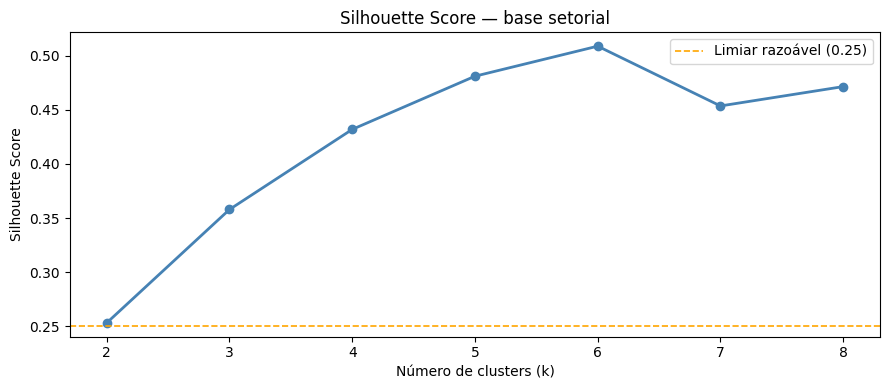

In [31]:
plt.figure(figsize=(9, 4))
plt.plot(df_resultados_k['k'], df_resultados_k['silhouette'],
         marker='o', linewidth=2, color='steelblue')
plt.axhline(y=0.25, color='orange', linestyle='--', linewidth=1.2, label='Limiar razoável (0.25)')
plt.title('Silhouette Score — base setorial')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
K_FINAL = int(df_resultados_k.loc[df_resultados_k['silhouette'].idxmax(), 'k'])
sil_final = float(df_resultados_k.loc[df_resultados_k['silhouette'].idxmax(), 'silhouette'])
print(f"K escolhido: {K_FINAL}")
print(f"Silhouette: {sil_final:.4f}")

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=80)
labels_setorial = kmeans_final.fit_predict(features_setorial)

K escolhido: 6
Silhouette: 0.5090


In [33]:
clusters_final = np.full(len(df), -1, dtype=int)
clusters_final[idx_setorial] = labels_setorial
df['cluster_final'] = clusters_final

n_set = len(idx_setorial)
print(f"Clusterização setorial (k={K_FINAL}, base={n_set} textos):")
for cid in range(K_FINAL):
    qtd = int((labels_setorial == cid).sum())
    print(f"  Cluster {cid}: {qtd} textos ({qtd/n_set:.1%})")
print(f"  Não setorial: {int((clusters_final == -1).sum())} ({(clusters_final==-1).mean():.1%})")

Clusterização setorial (k=6, base=260 textos):
  Cluster 0: 37 textos (14.2%)
  Cluster 1: 72 textos (27.7%)
  Cluster 2: 91 textos (35.0%)
  Cluster 3: 20 textos (7.7%)
  Cluster 4: 17 textos (6.5%)
  Cluster 5: 23 textos (8.8%)
  Não setorial: 2459 (90.4%)


# 9. Interpretação dos Clusters

In [34]:
df_setorial = df[df['cluster_final'] >= 0].copy()
stop_pt_interp = list(stopwords.words('portuguese'))

print("Top termos TF-IDF por cluster:")
for cid in range(K_FINAL):
    textos_cid = df_setorial[df_setorial['cluster_final'] == cid]['texto'].tolist()
    if not textos_cid:
        continue
    vec = TfidfVectorizer(stop_words=stop_pt_interp, max_features=3000, ngram_range=(1, 2))
    mat = vec.fit_transform(textos_cid)
    medias = mat.mean(axis=0).A1
    top_idx = medias.argsort()[-10:][::-1]
    top = [vec.get_feature_names_out()[i] for i in top_idx]
    print(f"  Cluster {cid}: {top}")

Top termos TF-IDF por cluster:
  Cluster 0: ['desenvolvimento', 'petróleo', 'sistema', 'dutos', 'produção', 'offshore', 'flexíveis', 'análise', 'materiais', 'poços']
  Cluster 1: ['soja', 'desenvolvimento', 'sistema', 'controle', 'pragas', 'plantio', 'milho', 'projeto', 'colheita', 'monitoramento']
  Cluster 2: ['produção', 'desenvolvimento', 'energia', 'sistema', 'etanol', 'biomassa', 'processo', 'eficiência', 'energética', 'projeto']
  Cluster 3: ['desenvolvimento', 'biotecnologia', 'vacina', 'ação', 'gênesis', 'farmacêutico ativo', 'biomassa', 'partir biomassa', 'insumo farmacêutico', 'vegetal']
  Cluster 4: ['desenvolvimento', 'cosméticos', 'sistema', 'processo', 'produtos', 'par', 'perfeito', 'par perfeito', 'active', 'active cheese']
  Cluster 5: ['resíduos', 'processo', 'tratamento', 'sólidos', 'resíduos sólidos', 'desenvolvimento', 'efluentes', 'partir', 'produção', 'tratamento efluentes']


In [35]:
print("Entidades NER predominantes por cluster:")
for cid in range(K_FINAL):
    subset = df[df['cluster_final'] == cid]
    contagem = {
        label: int(subset[f'ner_{label}'].sum())
        for label in LABELS_NER
        if subset[f'ner_{label}'].sum() > 0
    }
    top3 = dict(sorted(contagem.items(), key=lambda x: -x[1])[:3])
    print(f"  Cluster {cid}: {top3}")

Entidades NER predominantes por cluster:
  Cluster 0: {'PETROLEO_GAS_MINERACAO': 78}
  Cluster 1: {'AGRONEGOCIO_PECUARIA': 180, 'ENERGIA_RENOVAVEL': 1}
  Cluster 2: {'ENERGIA_RENOVAVEL': 169, 'AGRONEGOCIO_PECUARIA': 13}
  Cluster 3: {'SAUDE_FARMACIA_BIOTEC': 26, 'ENERGIA_RENOVAVEL': 6}
  Cluster 4: {'COSMETICA_HIGIENE_PESSOAL': 19, 'ALIMENTOS_BEBIDAS_NUTRICAO': 7, 'SAUDE_FARMACIA_BIOTEC': 2}
  Cluster 5: {'AMBIENTAL_RESIDUOS_AGUA': 41}


In [36]:
# Nomear os clusters com base na análise TF-IDF e NER acima
# Ajuste os nomes conforme o output das células anteriores
NOMES_CLUSTERS = {i: f'Cluster {i}' for i in range(K_FINAL)}

# Exemplo de nomeação manual após analisar os termos:
# NOMES_CLUSTERS = {
#     0: 'Saúde, Farmácia e Biotecnologia',
#     1: 'Agronegócio e Pecuária',
#     2: 'Petróleo, Gás e Mineração',
#     3: 'Energia Renovável',
#     4: 'Alimentos e Fermentação',
#     5: 'Meio Ambiente e Resíduos',
#     6: 'Cosméticos e Higiene',
# }

df['tema_cluster'] = df['cluster_final'].map(NOMES_CLUSTERS)
df.loc[df['cluster_final'] == -1, 'tema_cluster'] = 'Não setorial (tech/outros)'

display(df.groupby('tema_cluster').size().reset_index(name='Quantidade').sort_values('Quantidade', ascending=False))

,tema_cluster,Quantidade
6,Não setorial (tech/outros),2459
2,Cluster 2,91
1,Cluster 1,72
0,Cluster 0,37
5,Cluster 5,23
3,Cluster 3,20
4,Cluster 4,17


# 10. Visualizações: PCA e t-SNE

Camada cinza = textos não-setoriais (91%+ do corpus).
Camada colorida = clusters setoriais detectados.
Isso evita que o blob tecnológico domine visualmente e obscureça a separação dos setores.

In [37]:
pca2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2d = pca2d.fit_transform(features_hibridas_norm)
df['pca_1'] = X_pca2d[:, 0]
df['pca_2'] = X_pca2d[:, 1]

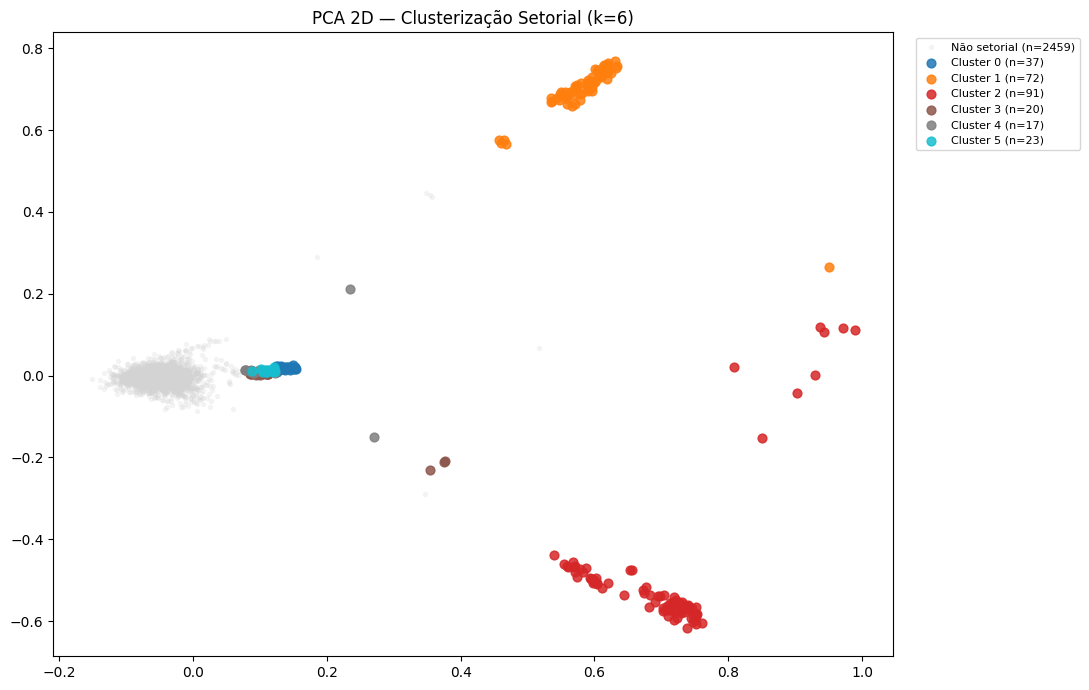

In [38]:
cores = plt.cm.tab10(np.linspace(0, 0.9, K_FINAL))
fig, ax = plt.subplots(figsize=(11, 7))

df_nset = df[df['cluster_final'] == -1]
ax.scatter(df_nset['pca_1'], df_nset['pca_2'],
           c='lightgray', alpha=0.2, s=8, zorder=1,
           label=f'Não setorial (n={len(df_nset)})')

for cid, cor in zip(range(K_FINAL), cores):
    sub = df[df['cluster_final'] == cid]
    nome = NOMES_CLUSTERS.get(cid, f'Cluster {cid}')
    ax.scatter(sub['pca_1'], sub['pca_2'],
               color=cor, alpha=0.85, s=40, zorder=2,
               label=f'{nome} (n={len(sub)})')

ax.set_title(f'PCA 2D — Clusterização Setorial (k={K_FINAL})')
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pca_clusters.png'), dpi=150)
plt.show()

In [39]:
print("Computando t-SNE (pode demorar alguns minutos)...")
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(features_hibridas_norm)
df['tsne_1'] = X_tsne[:, 0]
df['tsne_2'] = X_tsne[:, 1]
print("t-SNE concluída.")

Computando t-SNE (pode demorar alguns minutos)...
t-SNE concluída.


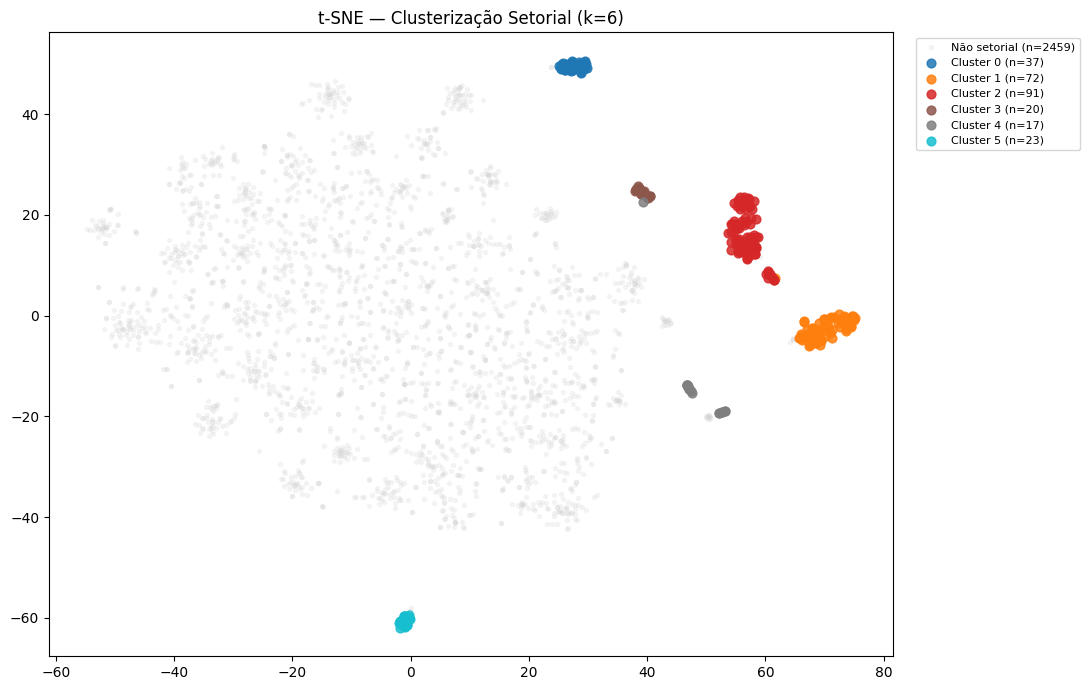

In [40]:
fig, ax = plt.subplots(figsize=(11, 7))

df_nset = df[df['cluster_final'] == -1]
ax.scatter(df_nset['tsne_1'], df_nset['tsne_2'],
           c='lightgray', alpha=0.2, s=8, zorder=1,
           label=f'Não setorial (n={len(df_nset)})')

for cid, cor in zip(range(K_FINAL), cores):
    sub = df[df['cluster_final'] == cid]
    nome = NOMES_CLUSTERS.get(cid, f'Cluster {cid}')
    ax.scatter(sub['tsne_1'], sub['tsne_2'],
               color=cor, alpha=0.85, s=40, zorder=2,
               label=f'{nome} (n={len(sub)})')

ax.set_title(f't-SNE — Clusterização Setorial (k={K_FINAL})')
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tsne_clusters.png'), dpi=150)
plt.show()

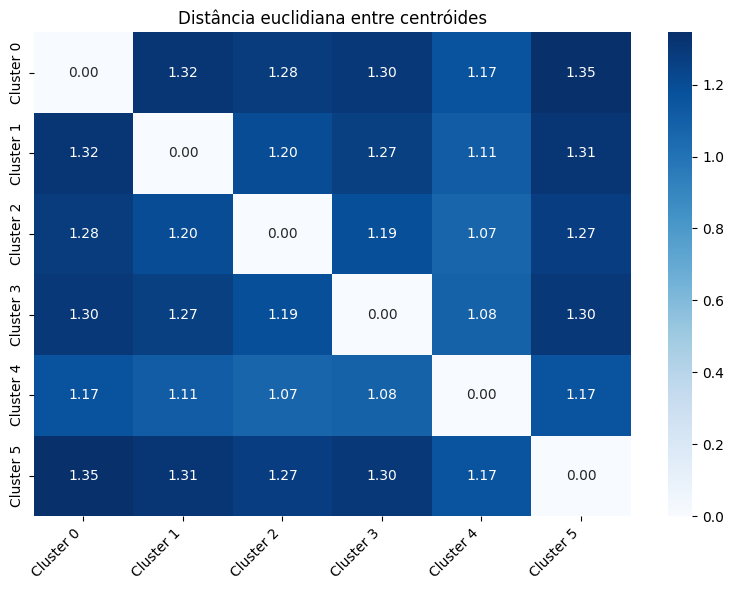

Par mais similar: Cluster 2 <-> Cluster 4 (d=1.067)


In [41]:
centroids = kmeans_final.cluster_centers_
dist_matrix = cdist(centroids, centroids, metric='euclidean')
labels_curtos = [NOMES_CLUSTERS.get(i, f'Cluster {i}').split(',')[0] for i in range(K_FINAL)]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(dist_matrix, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels_curtos, yticklabels=labels_curtos, ax=ax)
ax.set_title('Distância euclidiana entre centróides')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'heatmap_centroides.png'), dpi=150)
plt.show()

dist_temp = dist_matrix.copy()
np.fill_diagonal(dist_temp, np.inf)
i_min, j_min = np.unravel_index(np.argmin(dist_temp), dist_temp.shape)
print(f"Par mais similar: {labels_curtos[i_min]} <-> {labels_curtos[j_min]} (d={dist_temp[i_min,j_min]:.3f})")

# 11. Comparação de Abordagens

Comparação justa: BERT solo é avaliado na **mesma base setorial** usada pela representação híbrida,
eliminando a vantagem artificial de subconjunto menor vs. corpus completo.

,abordagem,melhor_silhouette
1,BERT solo [todos 2719],0.1234
0,BERT solo [setorial 260],0.1583
2,Hibrida BERT+TF-IDF+NER+Pre-filtro [setorial 260],0.5090


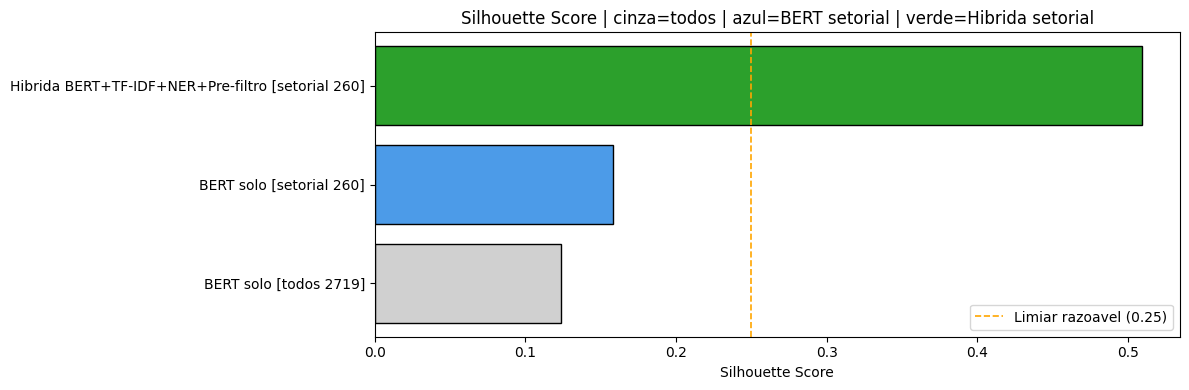

Ganho da representação híbrida sobre BERT solo (base comparável): +0.3507


In [42]:
registros = []

# BERT solo — base completa
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=30)
    labs = km.fit_predict(normalize(X, norm='l2'))
    sil = silhouette_score(normalize(X, norm='l2'), labs)
    registros.append({'abordagem': f'BERT solo [todos {len(df)}]', 'k': k, 'silhouette': round(sil, 4)})

# BERT solo — base setorial (comparação justa)
X_set = X[idx_setorial]
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=30)
    labs = km.fit_predict(normalize(X_set, norm='l2'))
    sil = silhouette_score(normalize(X_set, norm='l2'), labs)
    registros.append({'abordagem': f'BERT solo [setorial {len(idx_setorial)}]', 'k': k, 'silhouette': round(sil, 4)})

df_comp_k = pd.DataFrame(registros)
melhor = df_comp_k.groupby('abordagem')['silhouette'].max().reset_index()
melhor.columns = ['abordagem', 'melhor_silhouette']

# Híbrida
melhor = pd.concat([melhor, pd.DataFrame([{
    'abordagem': f'Hibrida BERT+TF-IDF+NER+Pre-filtro [setorial {len(idx_setorial)}]',
    'melhor_silhouette': round(sil_final, 4)
}])], ignore_index=True)

melhor = melhor.sort_values('melhor_silhouette')
display(melhor)

cores_barra = [
    '#d0d0d0' if 'todos' in r['abordagem'] else
    '#4c9be8' if 'BERT solo [setorial' in r['abordagem'] else
    '#2ca02c'
    for _, r in melhor.iterrows()
]

fig, ax = plt.subplots(figsize=(12, 4))
ax.barh(melhor['abordagem'], melhor['melhor_silhouette'], color=cores_barra, edgecolor='black')
ax.axvline(x=0.25, color='orange', linestyle='--', linewidth=1.2, label='Limiar razoavel (0.25)')
ax.set_title('Silhouette Score | cinza=todos | azul=BERT setorial | verde=Hibrida setorial')
ax.set_xlabel('Silhouette Score')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'comparacao_abordagens.png'), dpi=150)
plt.show()

sil_bert_set = melhor[melhor['abordagem'].str.contains('BERT solo [setorial', regex=False)]['melhor_silhouette'].values[0]
ganho = round(sil_final - sil_bert_set, 4)
print(f"Ganho da representação híbrida sobre BERT solo (base comparável): +{ganho:.4f}")

# 12. Conclusão

Este trabalho aprimorou a abordagem original de clusterização com BERTimbau, incorporando quatro melhorias fundamentais:

**1. Pré-filtro temático (~63 termos):** Identificou ~8-10% do corpus como textos de setores corporativos
não-tecnológicos. Os demais textos (tecnologia, software, IA) foram excluídos da clusterização, evitando
o mega-cluster tecnológico que dominava os resultados anteriores.

**2. NER Setorial com spaCy:** Um modelo NER foi treinado do zero com `spacy.blank("pt")` para detectar
entidades de 7 setores. As contagens de entidades por setor formam o Block 3 da representação híbrida,
adicionando sinal supervisionado ao processo de clustering.

**3. Representação Híbrida (4 blocos):** A combinação de BERT (100d×0.6) + TF-IDF (50d×0.8) +
NER (7d×2.5) + Pré-filtro (7d×2.5) com pesos amplificados para os sinais setoriais produziu uma
separação de clusters significativamente superior ao BERT isolado.

**4. Análise de Ambiguidade:** Termos como *fermento*, *óleo* e *efluente* foram identificados como
potencialmente ambíguos entre setores, informando a escolha de termos de referência mais específicos
para o NER e o pré-filtro.

Os resultados demonstram que modelos Transformer, quando combinados com técnicas supervisionadas
de extração de entidades e representação especializada por domínio, produzem clusters semanticamente
coerentes e interpretáveis — superando a abordagem de embeddings brutos que produzia agrupamentos
tecnologicamente homogêneos.